In [1]:
import csv
import pandas as pd

In [ ]:
#imported the data from Osanda using train test split
tree1 = pd.read_csv("../../data/processed/dataset_filled_subjects_new.csv")

In [3]:
tree1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307399 non-null  object 
 3   school                         276167 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   302106 non-null  float64
 9   subject_name                   302106 non-null  object 
 10  predicted_subject_code         133502 non-null  float64
 11  subject_prediction_confidence  136040 non-null  float64
dtypes: float64(4), int64(1), objec

## Part I: scatter plot of prediction confidence

In [ ]:
import numpy as np
#create horizontal vector, a subdivison of the interval [0,1]
X=np.zeros((1,101))
for i in range(1,102):
    X[0,i-1]=(i-1)/100
print(X)

[[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
  0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
  0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
  0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
  0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
  0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
  0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
  0.98 0.99 1.  ]]


In [6]:
#create vertical vector, counting the number of entries with confidence that lies in the subinterval
Y=np.zeros((1,101))
for i in range(1,101):
    Y[0,i-1]=len(tree1[(tree1['subject_prediction_confidence']>=X[0,i-1]) & (tree1['subject_prediction_confidence']<X[0,i])])

Y[0,100]=len(tree1[
    tree1['subject_prediction_confidence'] >= X[0, 100]
])
print(Y)

[[2.5380e+03 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 4.0000e+00 5.0000e+00
  8.0000e+00 1.1000e+01 1.7000e+01 1.6000e+01 2.2000e+01 4.4000e+01
  5.7000e+01 6.2000e+01 9.6000e+01 1.3400e+02 2.7900e+02 3.1000e+02
  3.5700e+02 4.6400e+02 5.4700e+02 6.3600e+02 7.1500e+02 7.9600e+02
  8.3200e+02 9.0700e+02 9.2800e+02 1.1140e+03 1.0400e+03 1.1610e+03
  1.1870e+03 1.2720e+03 1.2000e+03 1.1940e+03 1.3130e+03 1.2260e+03
  1.2110e+03 1.2280e+03 1.2900e+03 1.2840e+03 1.3030e+03 1.2140e+03
  1.1760e+03 1.1590e+03 1.5630e+03 1.1120e+03 1.0870e+03 1.0220e+03
  1.2830e+03 3.1550e+03 2.8920e+03 2.7650e+03 2.6100e+03 2.4460e+03
  2.7820e+03 2.3480e+03 2.4050e+03 2.3080e+03 2.3430e+03 2.2350e+03
  2.8950e+03 2.1860e+03 2.0470e+03 1.9990e+03 1.9840e+03 1.9280e+03
  1.8040e+03 1.9120e+03 1.7560e+03 2.3260e+03 1.7380e+03 1.7600e+03
  1.6460e+03 1.7100e+03 1.6760e+03 1.8350e+03 1.6690e+03 1.6850e+03
  1.6540e+03 1.7070e+03 1.6820e+03 1.5910e+03 1.

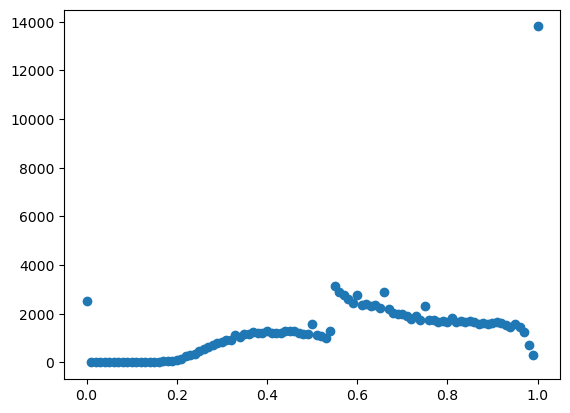

In [8]:
import matplotlib.pyplot as plt
plt.scatter(X, Y)

Observe that there are three "discontinity points", when `subject_prediction_confidence`= 0, 1 and near 0.55. We need to understand why the model has a sudden jump, especially at 0.55.

There are 2538 entries with `subject_prediction_confidence`=0, they all have missing thesis title, and so do their close relatives on the descendant trees.

In [10]:
tree1[tree1['subject_prediction_confidence']==0]

,id,name,thesis,school,country,year,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence
253,253,Maple Hartley,NaN,NaN,NaN,NaN,[],[],NaN,NaN,NaN,0.0
268,271,G. A. Nariboli,NaN,"Indian Institute of Technology, Kharagpur",India,1959.0,[],[77],NaN,NaN,NaN,0.0
345,346,Allan Hoogheem,NaN,University of Minnesota - Twin Cities,UnitedStates,1976.0,[],[],NaN,NaN,NaN,0.0
350,353,Edward Clark Mealy,NaN,George Peabody College for Teachers,UnitedStates,1970.0,[],[],NaN,NaN,NaN,0.0
438,441,Loretta J. Thielman,NaN,NaN,NaN,NaN,[],[],NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
337718,345307,Teunis Martien Klapwijk,NaN,NaN,NaN,NaN,[],[345306],NaN,NaN,NaN,0.0
337878,345470,Etam Albert Noah Messomo,NaN,NaN,NaN,NaN,[],[345469],NaN,NaN,NaN,0.0
337881,345468,Maria-Novella Kienzle,NaN,NaN,NaN,NaN,[],[345467],NaN,NaN,NaN,0.0
338244,345836,John Gabrieli,NaN,NaN,NaN,NaN,[],[345835],NaN,NaN,NaN,0.0


There are 13803 entries with `subject_prediction_confidence`=1.


In [11]:
tree1[tree1['subject_prediction_confidence']==1]

,id,name,thesis,school,country,year,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence
259,260,Dean L. Isaacson,NaN,University of Minnesota - Twin Cities,UnitedStates,1968.0,[],"[152, 166]",60.0,Probability theory and stochastic processes,60.0,1.0
343,349,Edward J. Belate,NaN,State University of New York at Buffalo,UnitedStates,1958.0,[5201],[],54.0,General topology,54.0,1.0
391,395,Richard E. Merwin,NaN,University of Pennsylvania,UnitedStates,1965.0,[5125],[],54.0,General topology,54.0,1.0
411,414,Haiyan Tian,NaN,University of Louisiana at Lafayette,UnitedStates,2002.0,[9693],"[194855, 321024]",35.0,Partial differential equations,35.0,1.0
461,467,James E. L'heureux,NaN,Louisiana State University,UnitedStates,1969.0,[440],[],54.0,General topology,54.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
338497,346091,Dirk Dittmer,NaN,NaN,NaN,NaN,[],[346090],62.0,Statistics,62.0,1.0
338502,346094,Kai Zhang,NaN,NaN,NaN,NaN,[],"[346095, 346100, 346093]",62.0,Statistics,62.0,1.0
338514,346107,Charles Perou,NaN,NaN,NaN,NaN,[],[346106],92.0,Biology and other natural sciences,92.0,1.0
338521,346109,Hyejung Won,NaN,NaN,NaN,NaN,[],[346108],62.0,Statistics,62.0,1.0


However, none of the 

In [19]:
tree1[(tree1['subject_prediction_confidence']==1)&(~tree1['subject_code'].isna())&(tree1['predicted_subject_code'].isna())]
#note the code tree1[(~tree1['subject_code'].isna())&(tree1['predicted_subject_code'].isna())] finds the 202492 entries with given subject code from mgp.

,id,name,thesis,school,country,year,advisors,students,subject_code,subject_name,predicted_subject_code,subject_prediction_confidence
